In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zoneinfo import ZoneInfo

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

SYDNEY = ZoneInfo("Australia/Sydney")
CDT = ZoneInfo("America/Chicago")

ACCOUNT_CAPITAL_USD = 100_000
CONTRACT_MULTIPLIER = 100_000
NUM_BUTTERFLIES = 5

MARKET_TICKER = "6A=F"

print("Setup done.")

Setup done.


In [56]:
ENTRY_TIME_SYDNEY = pd.Timestamp("2026-05-04 10:30", tz=SYDNEY)
EXIT_TIME_SYDNEY = pd.Timestamp("2026-05-06 15:30", tz=SYDNEY)

# June AUD/USD options on CME 6A futures
EXPIRY_TIME_SYDNEY = pd.Timestamp("2026-06-06 00:00", tz=SYDNEY)

legs = pd.DataFrame([
    {
        "leg": "Long 0.7200 call",
        "strike": 0.7200,
        "qty": 1 * NUM_BUTTERFLIES,
        "entry_action": "Buy",
        "entry_time_sydney": "2026-05-04 10:30",
        "entry_price": 0.0032,
        "exit_action": "Sell",
        "exit_time_sydney": "2026-05-06 15:30",
        "exit_price": 0.0067,
    },
    {
        "leg": "Short 2x 0.7275 calls",
        "strike": 0.7275,
        "qty": -2 * NUM_BUTTERFLIES,
        "entry_action": "Sell",
        "entry_time_sydney": "2026-05-04 10:31",
        "entry_price": 0.0011,
        "exit_action": "Buy back",
        "exit_time_sydney": "2026-05-06 15:31",
        "exit_price": 0.0019,
    },
    {
        "leg": "Long 0.7350 call",
        "strike": 0.7350,
        "qty": 1 * NUM_BUTTERFLIES,
        "entry_action": "Buy",
        "entry_time_sydney": "2026-05-04 10:32",
        "entry_price": 0.0003,
        "exit_action": "Sell",
        "exit_time_sydney": "2026-05-06 15:32",
        "exit_price": 0.00005,
    },
])

legs["entry_time_sydney"] = pd.to_datetime(legs["entry_time_sydney"]).dt.tz_localize(SYDNEY)
legs["exit_time_sydney"] = pd.to_datetime(legs["exit_time_sydney"]).dt.tz_localize(SYDNEY)

legs["entry_time_cdt"] = legs["entry_time_sydney"].dt.tz_convert(CDT)
legs["exit_time_cdt"] = legs["exit_time_sydney"].dt.tz_convert(CDT)

legs

,leg,strike,qty,entry_action,entry_time_sydney,entry_price,exit_action,exit_time_sydney,exit_price,entry_time_cdt,exit_time_cdt
0,Long 0.7200 call,0.720000,5,Buy,2026-05-04 10:30:00+10:00,0.003200,Sell,2026-05-06 15:30:00+10:00,0.006700,2026-05-03 19:30:00-05:00,2026-05-06 00:30:00-05:00
1,Short 2x 0.7275 calls,0.727500,-10,Sell,2026-05-04 10:31:00+10:00,0.001100,Buy back,2026-05-06 15:31:00+10:00,0.001900,2026-05-03 19:31:00-05:00,2026-05-06 00:31:00-05:00
2,Long 0.7350 call,0.735000,5,Buy,2026-05-04 10:32:00+10:00,0.000300,Sell,2026-05-06 15:32:00+10:00,0.000050,2026-05-03 19:32:00-05:00,2026-05-06 00:32:00-05:00


In [57]:
legs["entry_cash_usd"] = -legs["qty"] * legs["entry_price"] * CONTRACT_MULTIPLIER
legs["exit_cash_usd"] = legs["qty"] * legs["exit_price"] * CONTRACT_MULTIPLIER
legs["pnl_usd"] = legs["entry_cash_usd"] + legs["exit_cash_usd"]

legs["premium_paid_at_entry_usd"] = np.where(
    legs["qty"] > 0,
    legs["qty"] * legs["entry_price"] * CONTRACT_MULTIPLIER,
    0
)

legs["premium_received_at_entry_usd"] = np.where(
    legs["qty"] < 0,
    abs(legs["qty"]) * legs["entry_price"] * CONTRACT_MULTIPLIER,
    0
)

total_entry_cash_usd = legs["entry_cash_usd"].sum()
net_debit_usd = -total_entry_cash_usd

realized_pnl_usd = legs["pnl_usd"].sum()
return_on_net_debit = realized_pnl_usd / net_debit_usd
return_on_account = realized_pnl_usd / ACCOUNT_CAPITAL_USD

gross_premium_paid_usd = legs["premium_paid_at_entry_usd"].sum()
gross_premium_received_usd = legs["premium_received_at_entry_usd"].sum()

width_points = 0.7275 - 0.7200
net_debit_points_per_butterfly = net_debit_usd / (NUM_BUTTERFLIES * CONTRACT_MULTIPLIER)

lower_breakeven = 0.7200 + net_debit_points_per_butterfly
upper_breakeven = 0.7350 - net_debit_points_per_butterfly

max_intrinsic_value_usd = width_points * NUM_BUTTERFLIES * CONTRACT_MULTIPLIER
max_profit_usd = max_intrinsic_value_usd - net_debit_usd
max_loss_usd = net_debit_usd

summary_realized = pd.DataFrame({
    "Metric": [
        "Account capital, USD",
        "Number of butterflies",
        "Gross premium paid, USD",
        "Gross premium received, USD",
        "Net debit paid, USD",
        "Maximum possible loss, USD",
        "Maximum possible profit at expiry, USD",
        "Realized PnL, USD",
        "Return on net debit",
        "Return on account capital",
        "Lower breakeven",
        "Upper breakeven",
    ],
    "Value": [
        ACCOUNT_CAPITAL_USD,
        NUM_BUTTERFLIES,
        gross_premium_paid_usd,
        gross_premium_received_usd,
        net_debit_usd,
        max_loss_usd,
        max_profit_usd,
        realized_pnl_usd,
        return_on_net_debit,
        return_on_account,
        lower_breakeven,
        upper_breakeven,
    ]
})

display(legs[[
    "leg", "qty", "strike", "entry_price", "exit_price",
    "premium_paid_at_entry_usd",
    "premium_received_at_entry_usd", "pnl_usd"
]])

display(summary_realized)

,leg,qty,strike,entry_price,exit_price,premium_paid_at_entry_usd,premium_received_at_entry_usd,pnl_usd
0,Long 0.7200 call,5,0.720000,0.003200,0.006700,"1,600.000000",0.000000,"1,750.000000"
1,Short 2x 0.7275 calls,-10,0.727500,0.001100,0.001900,0.000000,"1,100.000000",-800.000000
2,Long 0.7350 call,5,0.735000,0.000300,0.000050,150.000000,0.000000,-125.000000


,Metric,Value
0,"Account capital, USD","100,000.000000"
1,Number of butterflies,5.000000
2,"Gross premium paid, USD","1,750.000000"
3,"Gross premium received, USD","1,100.000000"
4,"Net debit paid, USD",650.000000
5,"Maximum possible loss, USD",650.000000
6,"Maximum possible profit at expiry, USD","3,100.000000"
7,"Realized PnL, USD",825.000000
8,Return on net debit,1.269231
9,Return on account capital,0.008250


In [58]:
entry_rows = []
exit_rows = []

for _, row in legs.iterrows():
    entry_rows.append({
        "Date / time Sydney": row["entry_time_sydney"].strftime("%d %b %Y, %H:%M"),
        "Date / time CDT": row["entry_time_cdt"].strftime("%d %b %Y, %H:%M"),
        "Action": "Entered",
        "Instrument": "CME June AUD/USD option on 6A futures",
        "Position": f'{row["entry_action"]} {abs(int(row["qty"]))}x {row["strike"]:.4f} call',
        "Price": row["entry_price"],
    })

    exit_rows.append({
        "Date / time Sydney": row["exit_time_sydney"].strftime("%d %b %Y, %H:%M"),
        "Date / time CDT": row["exit_time_cdt"].strftime("%d %b %Y, %H:%M"),
        "Action": "Manually closed",
        "Instrument": "CME June AUD/USD option on 6A futures",
        "Position": f'{row["exit_action"]} {abs(int(row["qty"]))}x {row["strike"]:.4f} call',
        "Price": row["exit_price"],
    })

trading_log = pd.DataFrame(entry_rows + exit_rows)
trading_log

,Date / time Sydney,Date / time CDT,Action,Instrument,Position,Price
0,"04 May 2026, 10:30","03 May 2026, 19:30",Entered,CME June AUD/USD option on 6A futures,Buy 5x 0.7200 call,0.003200
1,"04 May 2026, 10:31","03 May 2026, 19:31",Entered,CME June AUD/USD option on 6A futures,Sell 10x 0.7275 call,0.001100
2,"04 May 2026, 10:32","03 May 2026, 19:32",Entered,CME June AUD/USD option on 6A futures,Buy 5x 0.7350 call,0.000300
3,"06 May 2026, 15:30","06 May 2026, 00:30",Manually closed,CME June AUD/USD option on 6A futures,Sell 5x 0.7200 call,0.006700
4,"06 May 2026, 15:31","06 May 2026, 00:31",Manually closed,CME June AUD/USD option on 6A futures,Buy back 10x 0.7275 call,0.001900
5,"06 May 2026, 15:32","06 May 2026, 00:32",Manually closed,CME June AUD/USD option on 6A futures,Sell 5x 0.7350 call,0.000050


In [59]:
try:
    import yfinance as yf
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf

start_download = (ENTRY_TIME_SYDNEY.tz_convert("UTC") - pd.Timedelta(days=1)).date().isoformat()
end_download = (EXIT_TIME_SYDNEY.tz_convert("UTC") + pd.Timedelta(days=2)).date().isoformat()

market_raw = yf.download(
    MARKET_TICKER,
    start=start_download,
    end=end_download,
    interval="30m",
    auto_adjust=False,
    prepost=True,
    progress=False,
    ignore_tz=False
)

if market_raw.empty:
    print("30-minute data unavailable. Trying 1-hour data instead.")
    market_raw = yf.download(
        MARKET_TICKER,
        start=start_download,
        end=end_download,
        interval="1h",
        auto_adjust=False,
        prepost=True,
        progress=False,
        ignore_tz=False
    )

if market_raw.empty:
    raise ValueError("No market data downloaded. Check ticker, internet connection, or date range.")

if isinstance(market_raw.columns, pd.MultiIndex):
    market_raw.columns = market_raw.columns.get_level_values(0)

market_raw.columns.name = None
market = market_raw.reset_index()
market.columns.name = None

datetime_col = "Datetime" if "Datetime" in market.columns else "Date"

market["datetime"] = pd.to_datetime(market[datetime_col], utc=True)
market["datetime_sydney"] = market["datetime"].dt.tz_convert(SYDNEY)

market = market.rename(columns={"Close": "audusd_futures"})

market = market[
    (market["datetime_sydney"] >= ENTRY_TIME_SYDNEY) &
    (market["datetime_sydney"] <= EXIT_TIME_SYDNEY)
].copy()

market = market[[
    "datetime_sydney",
    "audusd_futures",
    "Open",
    "High",
    "Low",
    "Volume"
]]

if market.empty:
    raise ValueError("Market data downloaded, but no rows matched the trade window.")

market.to_csv("audusd_6A_futures_market_data_2026_05_04_to_2026_05_06.csv", index=False)

print("Real AUD/USD futures market data saved to CSV.")
market.tail()

Real AUD/USD futures market data saved to CSV.


,datetime_sydney,audusd_futures,Open,High,Low,Volume
103,2026-05-06 13:30:00+10:00,0.722700,0.723100,0.723300,0.722650,1112
104,2026-05-06 14:00:00+10:00,0.723600,0.722700,0.723600,0.722700,2862
105,2026-05-06 14:30:00+10:00,0.723900,0.723550,0.724550,0.723500,6019
106,2026-05-06 15:00:00+10:00,0.724000,0.723850,0.724400,0.723700,2276
107,2026-05-06 15:30:00+10:00,0.724250,0.724000,0.724400,0.723800,1494


In [60]:
checkpoint_source = market[
    (market["datetime_sydney"] >= ENTRY_TIME_SYDNEY) &
    (market["datetime_sydney"] <= EXIT_TIME_SYDNEY)
].copy()

if len(checkpoint_source) < 10:
    checkpoint_indices = np.arange(len(checkpoint_source))
else:
    checkpoint_indices = np.linspace(0, len(checkpoint_source) - 1, 10).round().astype(int)
    checkpoint_indices = sorted(set(checkpoint_indices))

checkpoints = checkpoint_source.iloc[checkpoint_indices].copy().reset_index(drop=True)

def strategy_zone(futures_price):
    if futures_price < 0.7200:
        return "Below lower strike, position under pressure"
    elif futures_price < lower_breakeven:
        return "Above 0.7200 but below lower breakeven"
    elif futures_price <= 0.7275:
        return "Profit zone, moving toward max profit"
    elif futures_price <= upper_breakeven:
        return "Profit zone, above max-profit strike"
    elif futures_price <= 0.7350:
        return "Above upper breakeven, profit fading"
    else:
        return "Above upper strike, max loss zone"

checkpoints["distance_to_0.7200"] = checkpoints["audusd_futures"] - 0.7200
checkpoints["distance_to_0.7275"] = checkpoints["audusd_futures"] - 0.7275
checkpoints["distance_to_0.7350"] = checkpoints["audusd_futures"] - 0.7350
checkpoints["strategy_zone"] = checkpoints["audusd_futures"].apply(strategy_zone)

checkpoint_dashboard = checkpoints[[
    "datetime_sydney",
    "audusd_futures",
    "distance_to_0.7200",
    "distance_to_0.7275",
    "distance_to_0.7350",
    "strategy_zone"
]].copy()

checkpoint_dashboard

,datetime_sydney,audusd_futures,distance_to_0.7200,distance_to_0.7275,distance_to_0.7350,strategy_zone
0,2026-05-04 10:30:00+10:00,0.720350,0.000350,-0.007150,-0.014650,Above 0.7200 but below lower breakeven
1,2026-05-04 16:00:00+10:00,0.720250,0.000250,-0.007250,-0.014750,Above 0.7200 but below lower breakeven
2,2026-05-04 22:00:00+10:00,0.718400,-0.001600,-0.009100,-0.016600,"Below lower strike, position under pressure"
3,2026-05-05 03:30:00+10:00,0.716400,-0.003600,-0.011100,-0.018600,"Below lower strike, position under pressure"
4,2026-05-05 10:00:00+10:00,0.715500,-0.004500,-0.012000,-0.019500,"Below lower strike, position under pressure"
5,2026-05-05 16:00:00+10:00,0.713950,-0.006050,-0.013550,-0.021050,"Below lower strike, position under pressure"
6,2026-05-05 21:30:00+10:00,0.716650,-0.003350,-0.010850,-0.018350,"Below lower strike, position under pressure"
7,2026-05-06 03:00:00+10:00,0.718100,-0.001900,-0.009400,-0.016900,"Below lower strike, position under pressure"
8,2026-05-06 10:00:00+10:00,0.720300,0.000300,-0.007200,-0.014700,Above 0.7200 but below lower breakeven
9,2026-05-06 15:30:00+10:00,0.724250,0.004250,-0.003250,-0.010750,"Profit zone, moving toward max profit"


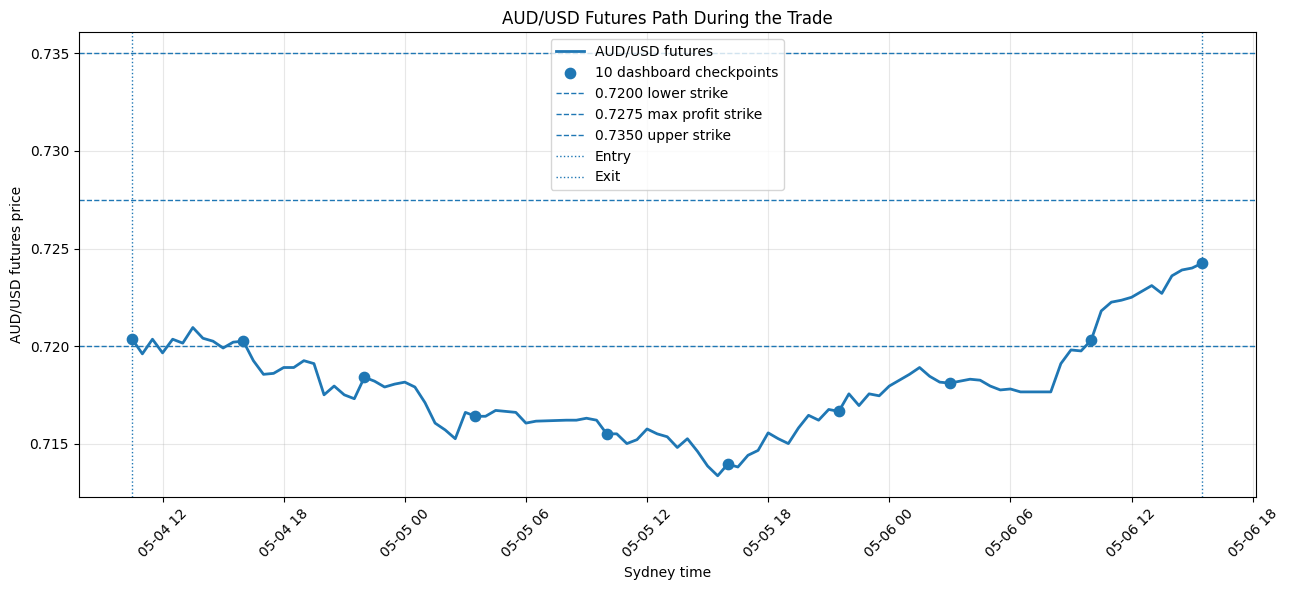

In [61]:
plt.figure(figsize=(13, 6))

plt.plot(
    market["datetime_sydney"],
    market["audusd_futures"],
    linewidth=2,
    label="AUD/USD futures"
)

plt.scatter(
    checkpoints["datetime_sydney"],
    checkpoints["audusd_futures"],
    s=55,
    label="10 dashboard checkpoints"
)

plt.axhline(0.7200, linestyle="--", linewidth=1, label="0.7200 lower strike")
plt.axhline(0.7275, linestyle="--", linewidth=1, label="0.7275 max profit strike")
plt.axhline(0.7350, linestyle="--", linewidth=1, label="0.7350 upper strike")

plt.axvline(ENTRY_TIME_SYDNEY, linestyle=":", linewidth=1, label="Entry")
plt.axvline(EXIT_TIME_SYDNEY, linestyle=":", linewidth=1, label="Exit")

plt.title("AUD/USD Futures Path During the Trade")
plt.xlabel("Sydney time")
plt.ylabel("AUD/USD futures price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

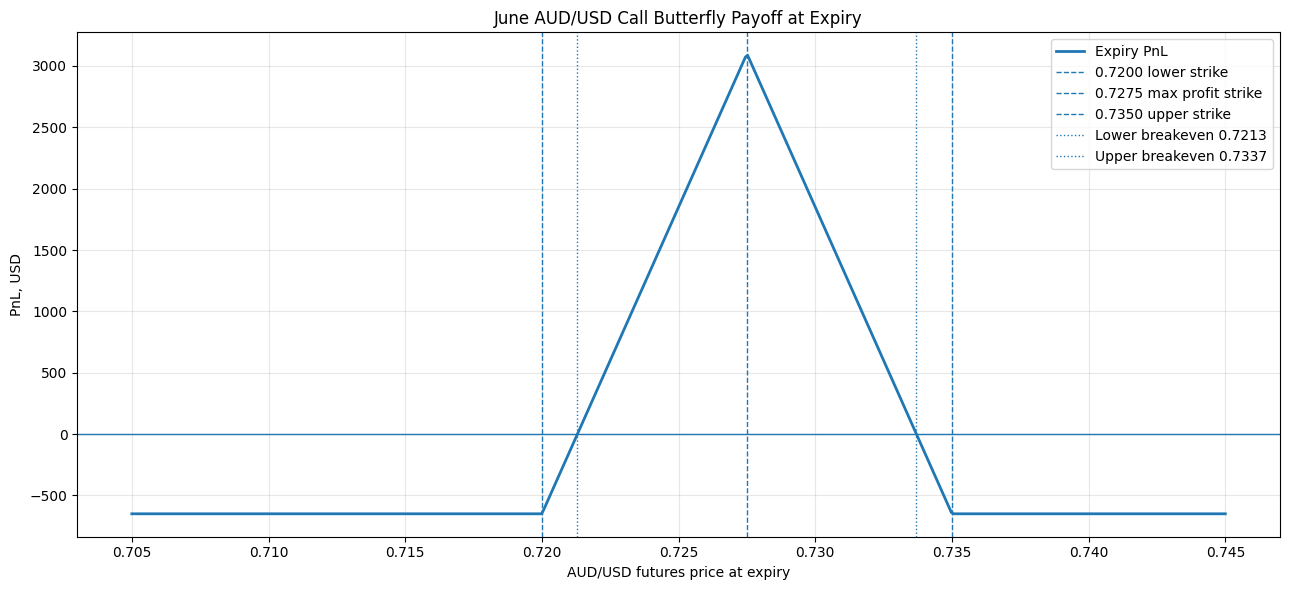

Net debit paid: 0.001300 points per butterfly = $650.00
Maximum intrinsic value before premium: $3,750.00
Maximum profit after premium: $3,100.00
Maximum loss: $650.00
Lower breakeven: 0.721300
Upper breakeven: 0.733700


In [62]:
S = np.linspace(0.7050, 0.7450, 500)

expiry_intrinsic_value = np.zeros_like(S)

for _, row in legs.iterrows():
    expiry_intrinsic_value += (
        row["qty"]
        * np.maximum(S - row["strike"], 0)
        * CONTRACT_MULTIPLIER
    )

expiry_pnl = expiry_intrinsic_value + total_entry_cash_usd

plt.figure(figsize=(13, 6))

plt.plot(S, expiry_pnl, linewidth=2, label="Expiry PnL")
plt.axhline(0, linewidth=1)

plt.axvline(0.7200, linestyle="--", linewidth=1, label="0.7200 lower strike")
plt.axvline(0.7275, linestyle="--", linewidth=1, label="0.7275 max profit strike")
plt.axvline(0.7350, linestyle="--", linewidth=1, label="0.7350 upper strike")

plt.axvline(lower_breakeven, linestyle=":", linewidth=1, label=f"Lower breakeven {lower_breakeven:.4f}")
plt.axvline(upper_breakeven, linestyle=":", linewidth=1, label=f"Upper breakeven {upper_breakeven:.4f}")

plt.title("June AUD/USD Call Butterfly Payoff at Expiry")
plt.xlabel("AUD/USD futures price at expiry")
plt.ylabel("PnL, USD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Net debit paid: {net_debit_points_per_butterfly:.6f} points per butterfly = ${net_debit_usd:,.2f}")
print(f"Maximum intrinsic value before premium: ${max_intrinsic_value_usd:,.2f}")
print(f"Maximum profit after premium: ${max_profit_usd:,.2f}")
print(f"Maximum loss: ${max_loss_usd:,.2f}")
print(f"Lower breakeven: {lower_breakeven:.6f}")
print(f"Upper breakeven: {upper_breakeven:.6f}")

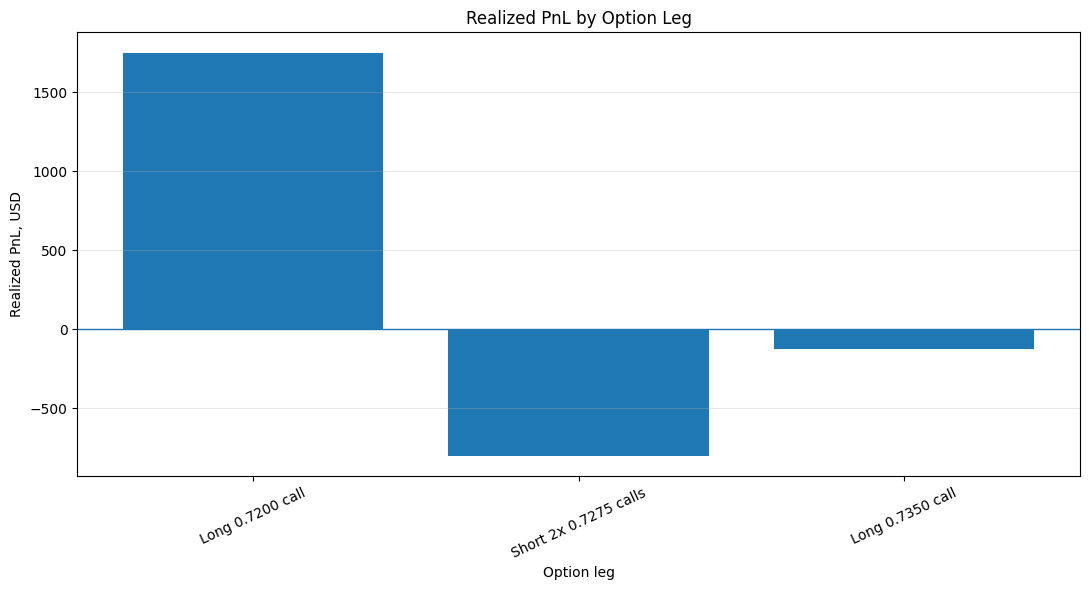

In [63]:
plt.figure(figsize=(11, 6))

plt.bar(legs["leg"], legs["pnl_usd"])

plt.axhline(0, linewidth=1)
plt.title("Realized PnL by Option Leg")
plt.xlabel("Option leg")
plt.ylabel("Realized PnL, USD")
plt.xticks(rotation=25)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
entry_futures_price = market.iloc[0]["audusd_futures"]
exit_futures_price = market.iloc[-1]["audusd_futures"]
futures_move = exit_futures_price - entry_futures_price

lowest_futures_price = market["audusd_futures"].min()
highest_futures_price = market["audusd_futures"].max()

closest_to_max_profit = checkpoint_dashboard.iloc[
    checkpoint_dashboard["distance_to_0.7275"].abs().idxmin()
]

final_summary = pd.DataFrame({
    "Metric": [
        "Strategy",
        "Instrument",
        "Market data source",
        "Entry date",
        "Exit date",
        "Account capital, USD",
        "Position size",
        "Entry futures price",
        "Exit futures price",
        "Futures move during trade",
        "Lowest futures price during trade",
        "Highest futures price during trade",
        "Net debit paid, USD",
        "Maximum possible loss, USD",
        "Maximum possible profit at expiry, USD",
        "Realized PnL, USD",
        "Return on net debit",
        "Return on account capital",
        "Closest checkpoint to max-profit strike",
        "Lower breakeven",
        "Upper breakeven",
    ],
    "Value": [
        "Long 100x 0.7200 / short 200x 0.7275 / long 100x 0.7350 call butterfly",
        "CME June AUD/USD options on 6A futures",
        "Yahoo Finance 6A=F, exported to CSV",
        ENTRY_TIME_SYDNEY.strftime("%d %b %Y, %H:%M Sydney"),
        EXIT_TIME_SYDNEY.strftime("%d %b %Y, %H:%M Sydney"),
        f"${ACCOUNT_CAPITAL_USD:,.2f}",
        f"{NUM_BUTTERFLIES} call butterflies",
        f"{entry_futures_price:.5f}",
        f"{exit_futures_price:.5f}",
        f"{futures_move:+.5f}",
        f"{lowest_futures_price:.5f}",
        f"{highest_futures_price:.5f}",
        f"${net_debit_usd:,.2f}",
        f"${max_loss_usd:,.2f}",
        f"${max_profit_usd:,.2f}",
        f"${realized_pnl_usd:,.2f}",
        f"{return_on_net_debit:.2%}",
        f"{return_on_account:.2%}",
        f'{closest_to_max_profit["datetime_sydney"].strftime("%d %b %Y, %H:%M Sydney")} at {closest_to_max_profit["audusd_futures"]:.5f}',
        f"{lower_breakeven:.6f}",
        f"{upper_breakeven:.6f}",
    ]
})

final_summary

,Metric,Value
0,Strategy,Long 100x 0.7200 / short 200x 0.7275 / long 100x 0.7350 call butterfly
1,Instrument,CME June AUD/USD options on 6A futures
2,Market data source,"Yahoo Finance 6A=F, exported to CSV"
3,Entry date,"04 May 2026, 10:30 Sydney"
4,Exit date,"06 May 2026, 15:30 Sydney"
5,"Account capital, USD","$100,000.00"
6,Position size,5 call butterflies
7,Entry futures price,0.72035
8,Exit futures price,0.72425
9,Futures move during trade,+0.00390


In [65]:
legs.to_csv("audusd_june_call_butterfly_legs.csv", index=False)
trading_log.to_csv("audusd_june_call_butterfly_trading_log.csv", index=False)
summary_realized.to_csv("audusd_june_call_butterfly_realized_summary.csv", index=False)
checkpoint_dashboard.to_csv("audusd_june_call_butterfly_10_checkpoint_dashboard.csv", index=False)
final_summary.to_csv("audusd_june_call_butterfly_final_summary.csv", index=False)

print("Exported files:")
print("1. audusd_6A_futures_market_data_2026_05_04_to_2026_05_06.csv")
print("2. audusd_june_call_butterfly_legs.csv")
print("3. audusd_june_call_butterfly_trading_log.csv")
print("4. audusd_june_call_butterfly_realized_summary.csv")
print("5. audusd_june_call_butterfly_10_checkpoint_dashboard.csv")
print("6. audusd_june_call_butterfly_final_summary.csv")

Exported files:
1. audusd_6A_futures_market_data_2026_05_04_to_2026_05_06.csv
2. audusd_june_call_butterfly_legs.csv
3. audusd_june_call_butterfly_trading_log.csv
4. audusd_june_call_butterfly_realized_summary.csv
5. audusd_june_call_butterfly_10_checkpoint_dashboard.csv
6. audusd_june_call_butterfly_final_summary.csv
